# Bab 5: Classification

**Buku:** *Practical Statistics for Data Scientists* (O'Reilly)

## Ringkasan Bab
Klasifikasi dipakai untuk memprediksi outcome yang **kategorikal** (gagal bayar atau lunas, spam atau bukan spam). Kebanyakan metode terlebih dahulu menghasilkan **probabilitas** untuk tiap kelas, lalu memakai **cutoff** untuk menentukan labelnya.

1. **Naive Bayes.** Teorema Bayes dengan asumsi independensi bersyarat.
2. **Discriminant analysis.** LDA mencari kombinasi linear yang paling memisahkan kelas.
3. **Regresi logistik.** GLM yang memodelkan log-odds, dengan koefisien yang ditafsirkan sebagai odds ratio.
4. **Evaluasi model.** Confusion matrix, precision, recall, specificity, kurva ROC, AUC, dan lift.
5. **Strategi untuk data tidak seimbang.** Undersampling, oversampling, pembobotan, SMOTE/ADASYN, dan keputusan berbasis biaya.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (confusion_matrix, precision_recall_fscore_support,
                             roc_curve, accuracy_score, roc_auc_score)
import statsmodels.api as sm
import statsmodels.formula.api as smf
from imblearn.over_sampling import SMOTE, ADASYN
from pygam import LinearGAM, s
from dmba import classificationSummary
import seaborn as sns
import matplotlib.pyplot as plt

DATA = Path('..') / 'data'
sns.set_style('whitegrid')
%matplotlib inline

no display found. Using non-interactive Agg backend


## 1. Naive Bayes
**Penjelasan teori.** Teorema Bayes memberikan peluang kelas $Y=i$ jika diketahui prediktor $X_1..X_p$:
$$P(Y=i\mid X)=\frac{P(Y=i)\prod_j P(X_j\mid Y=i)}{\sum_k P(Y=k)\prod_j P(X_j\mid Y=k)}$$
- Disebut *naive* karena mengasumsikan prediktor **independen secara bersyarat** pada kelasnya. Dengan asumsi ini kita cukup mengalikan peluang tiap variabel, tanpa perlu mencari record yang cocok persis dengan seluruh kombinasi prediktor (pendekatan Bayes eksak gagal kalau prediktornya banyak karena hampir tidak ada record dengan kombinasi yang sama).
- Cocok untuk prediktor kategorikal. Prediktor numerik harus dikelompokkan ke dalam bin atau dimodelkan dengan distribusi (Gaussian NB).
- Kelebihan: cepat, bisa dipakai dengan data sedikit, dan menangani banyak prediktor. Kekurangan: probabilitasnya sering kurang terkalibrasi, meskipun urutan peringkatnya biasanya bagus. Konstanta smoothing $\alpha$ yang kecil dipakai supaya tidak muncul peluang nol.

In [2]:
loan_data = pd.read_csv(DATA / 'loan_data.csv.gz')
loan_data['outcome'] = loan_data['outcome'].astype('category')
for c in ['purpose_', 'home_', 'emp_len_']:
    loan_data[c] = loan_data[c].astype('category')

predictors = ['purpose_', 'home_', 'emp_len_']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', dtype=int)
y = loan_data[outcome]

naive_model = MultinomialNB(alpha=1e-10, fit_prior=False)
naive_model.fit(X, y)

new_loan = X.loc[146:146, :]
print('predicted class: ', naive_model.predict(new_loan)[0])
probabilities = pd.DataFrame(naive_model.predict_proba(new_loan), columns=naive_model.classes_)
print('predicted probabilities')
print(probabilities)

predicted class:  default
predicted probabilities
    default  paid off
0  0.653699  0.346301


## 2. Discriminant Analysis
**Penjelasan teori.** **Linear Discriminant Analysis (LDA)** mencari kombinasi linear prediktor yang memaksimalkan rasio varians **antar kelas** terhadap varians **dalam kelas** (diskriminan linear Fisher). Asumsinya, prediktor kira-kira berdistribusi **normal multivariat** dengan **matriks kovarians yang sama** di tiap kelas. Outputnya berupa **bobot diskriminan** (`scalings`) dan probabilitas kelas. LDA berkerabat dekat dengan regresi logistik, dan dalam praktik hasilnya sering mirip. Quadratic discriminant analysis membolehkan kovarians yang berbeda untuk tiap kelas.

In [3]:
loan3000 = pd.read_csv(DATA / 'loan3000.csv')
loan3000['outcome'] = loan3000['outcome'].astype('category')

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'
X = loan3000[predictors]
y = loan3000[outcome]

loan_lda = LinearDiscriminantAnalysis()
loan_lda.fit(X, y)
print(pd.DataFrame(loan_lda.scalings_, index=X.columns, columns=['LD1']))

pred = pd.DataFrame(loan_lda.predict_proba(loan3000[predictors]), columns=loan_lda.classes_)
print(pred.head())

                        LD1
borrower_score     7.175839
payment_inc_ratio -0.099676
    default  paid off
0  0.553544  0.446456
1  0.558953  0.441047
2  0.272696  0.727304
3  0.506254  0.493746
4  0.609952  0.390048


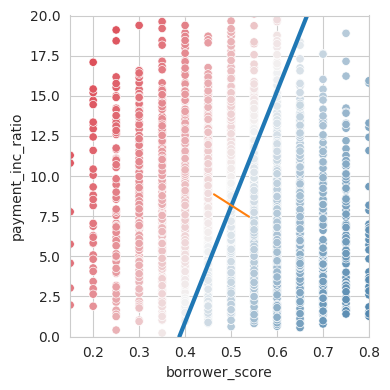

In [4]:
# LDA decision boundary (Fig. 5-1)
center = np.mean(loan_lda.means_, axis=0)
slope = -loan_lda.scalings_[0] / loan_lda.scalings_[1]
intercept = center[1] - center[0] * slope
x_0 = (0 - intercept) / slope
x_20 = (20 - intercept) / slope

lda_df = pd.concat([loan3000, pred['default']], axis=1)
fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(x='borrower_score', y='payment_inc_ratio', hue='default', data=lda_df,
                palette=sns.diverging_palette(240, 10, n=9, as_cmap=True), ax=ax, legend=False)
ax.set_ylim(0, 20); ax.set_xlim(0.15, 0.8)
ax.plot((x_0, x_20), (0, 20), linewidth=3)
ax.plot(*loan_lda.means_.transpose())
plt.tight_layout(); plt.show()

## 3. Regresi Logistik
**Penjelasan teori.** Regresi logistik memodelkan peluang $p$ untuk kelas "1" lewat link **logit** (log-odds):
$$\text{logit}(p)=\log\frac{p}{1-p}=b_0+b_1X_1+\dots+b_pX_p,\qquad p=\frac{1}{1+e^{-(b_0+b_1X_1+\dots)}}$$
- **Odds** $=p/(1-p)$, dan **odds ratio** membandingkan odds untuk dua nilai prediktor. Koefisien $b_j$ berarti: kenaikan satu satuan $X_j$ mengalikan odds dengan $e^{b_j}$.
- Parameternya diestimasi dengan **maximum likelihood** (iteratif), bukan kuadrat terkecil. Modelnya termasuk keluarga **generalized linear model (GLM)** dengan respons binomial dan link logit.
- Penilaiannya memakai **deviance** (−2 log-likelihood), AIC, serta statistik z dan p-value. Model bisa memuat variabel faktor, spline, dan interaksi, dan **partial residual plot** dipakai untuk memeriksa linearitas pada skala logit.

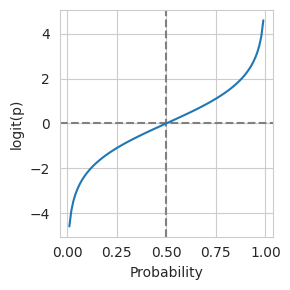

In [5]:
p = np.arange(0.01, 1, 0.01)
df = pd.DataFrame({'p': p, 'logit': np.log(p / (1 - p)), 'odds': p / (1 - p)})
fig, ax = plt.subplots(figsize=(3, 3))
ax.axhline(0, color='grey', linestyle='--'); ax.axvline(0.5, color='grey', linestyle='--')
ax.plot(df['p'], df['logit']); ax.set_xlabel('Probability'); ax.set_ylabel('logit(p)')
plt.tight_layout(); plt.show()

In [6]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', drop_first=True, dtype=int)
y = loan_data[outcome]

logit_reg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000)
logit_reg.fit(X, y)
print('intercept ', logit_reg.intercept_[0])
print('classes', logit_reg.classes_)
print(pd.DataFrame({'coeff': logit_reg.coef_[0]}, index=X.columns))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


intercept  -1.6323097208533766
classes ['default' 'paid off']
                       coeff
payment_inc_ratio  -0.079854
borrower_score      4.618623
debt_consolidation -0.250705
home_improvement   -0.408728
major_purchase     -0.228109
medical            -0.522404
other              -0.617895
small_business     -1.221105
OWN                -0.049230
RENT               -0.159339
 > 1 Year           0.350848


scikit-learn menganggap kelas *kedua* menurut urutan alfabet (`paid off`) sebagai kelas positif, jadi tanda koefisiennya **berlawanan** dengan model yang menarget `default`. Statsmodels di bawah memakai outcome 0/1 yang eksplisit (1 = default).

In [7]:
# Predicted values: log-odds and probabilities
pred = pd.DataFrame(logit_reg.predict_log_proba(X), columns=logit_reg.classes_)
print(pred.describe())
pred = pd.DataFrame(logit_reg.predict_proba(X), columns=logit_reg.classes_)
print(pred.describe())

            default      paid off
count  45342.000000  45342.000000
mean      -0.758254     -0.760454
std        0.378780      0.391064
min       -2.774245     -3.548142
25%       -0.986740     -0.977743
50%       -0.697659     -0.688656
75%       -0.471860     -0.466474
max       -0.029200     -0.064428
            default      paid off
count  45342.000000  45342.000000
mean       0.499917      0.500083
std        0.167572      0.167572
min        0.062397      0.028778
25%        0.372790      0.376159
50%        0.497749      0.502251
75%        0.623841      0.627210
max        0.971222      0.937603


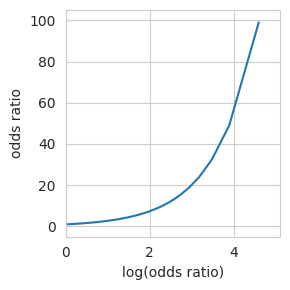

In [8]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(df['logit'], df['odds'])
ax.set_xlabel('log(odds ratio)'); ax.set_ylabel('odds ratio')
ax.set_xlim(0, 5.1); ax.set_ylim(-5, 105)
plt.tight_layout(); plt.show()

In [9]:
# GLM with statsmodels (binomial family) -> full inference table
y_numbers = [1 if yi == 'default' else 0 for yi in y]
logit_reg_sm = sm.GLM(y_numbers, X.assign(const=1), family=sm.families.Binomial())
logit_result = logit_reg_sm.fit()
print(logit_result.summary())
print('\nOdds ratios (exp of coefficients):')
print(np.exp(logit_result.params).round(3))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                45342
Model:                            GLM   Df Residuals:                    45330
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28757.
Date:                Fri, 02 Oct 2026   Deviance:                       57515.
Time:                        11:50:01   Pearson chi2:                 4.54e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1112
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
payment_inc_ratio      0.0797      0

In [10]:
# Nonlinear terms via splines
formula = ('outcome ~ bs(payment_inc_ratio, df=8) + purpose_ + home_ + emp_len_ + bs(borrower_score, df=3)')
loan_sm = loan_data.copy()
loan_sm['outcome'] = (loan_sm['outcome'] == 'default').astype(int)
model = smf.glm(formula=formula, data=loan_sm, family=sm.families.Binomial())
results = model.fit()
print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                outcome   No. Observations:                45342
Model:                            GLM   Df Residuals:                    45321
Model Family:                Binomial   Df Model:                           20
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28731.
Date:                Fri, 02 Oct 2026   Deviance:                       57462.
Time:                        11:50:02   Pearson chi2:                 4.54e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1122
Covariance Type:            nonrobust                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

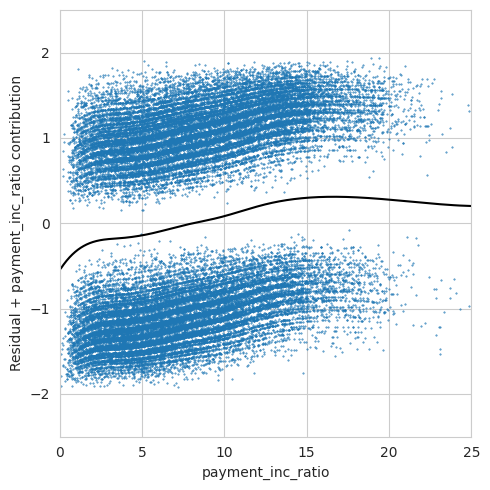

In [11]:
def partialResidualPlot(model, df, outcome, feature, fig, ax):
    y_actual = [0 if s == 'default' else 1 for s in df[outcome]]
    y_pred = model.predict(df)
    org_params = model.params.copy()
    zero_params = model.params.copy()
    for i, name in enumerate(zero_params.index):
        if feature in name:
            continue
        zero_params.iloc[i] = 0.0
    model.initialize(model.model, zero_params)
    feature_prediction = model.predict(df)
    ypartial = -np.log(1 / feature_prediction - 1)
    ypartial = ypartial - np.mean(ypartial)
    model.initialize(model.model, org_params)
    results = pd.DataFrame({'feature': df[feature],
                            'residual': -2 * (y_actual - y_pred),
                            'ypartial': ypartial / 2})
    results = results.sort_values(by=['feature'])
    ax.scatter(results.feature, results.residual, marker='.', s=72. / fig.dpi)
    ax.plot(results.feature, results.ypartial, color='black')
    ax.set_xlabel(feature); ax.set_ylabel(f'Residual + {feature} contribution')
    return ax

# the book's plot uses the original outcome labels (default / paid off) -> recompute y_actual consistently
loan_pr = loan_data.copy()
fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(results, loan_pr, 'outcome', 'payment_inc_ratio', fig, ax)
ax.set_xlim(0, 25); ax.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()

## 4. Evaluasi Model Klasifikasi
**Penjelasan teori.** **Akurasi** saja bisa menyesatkan kalau kelasnya jarang. Model yang selalu menjawab "tidak ada fraud" bisa saja akurat 99%.

**Confusion matrix** (baris = aktual, kolom = prediksi):

| | Prediksi positif | Prediksi negatif |
|---|---|---|
| **Aktual positif** | True Positive (TP) | False Negative (FN) |
| **Aktual negatif** | False Positive (FP) | True Negative (TN) |

- **Akurasi** $=\frac{TP+TN}{N}$ dan **Precision** $=\frac{TP}{TP+FP}$ (dari semua yang diprediksi positif, berapa yang benar).
- **Recall/sensitivitas** $=\frac{TP}{TP+FN}$ (dari semua yang aktual positif, berapa yang berhasil ditemukan) dan **Specificity** $=\frac{TN}{TN+FP}$.
- **F1** adalah rata-rata harmonik dari precision dan recall.
- **Kurva ROC** memplot recall terhadap specificity (atau FPR) saat **cutoff** diubah-ubah. **AUC** (luas di bawah kurva) merangkum kualitas peringkat model (0,5 berarti acak, 1 berarti sempurna).
- **Lift** menunjukkan seberapa lebih baik model dibanding pemilihan acak dalam menemukan kelas positif pada fraksi teratas skor (kurva **gains** kumulatif).

In [12]:
pred = logit_reg.predict(X)
pred_y = pred == 'default'
true_y = y == 'default'
true_pos = true_y & pred_y
true_neg = ~true_y & ~pred_y
false_pos = ~true_y & pred_y
false_neg = true_y & ~pred_y
conf_mat = pd.DataFrame([[np.sum(true_pos), np.sum(false_neg)], [np.sum(false_pos), np.sum(true_neg)]],
                        index=['Y = default', 'Y = paid off'],
                        columns=['Yhat = default', 'Yhat = paid off'])
print(conf_mat)
print(confusion_matrix(y, pred))
classificationSummary(y, pred, class_names=logit_reg.classes_)

              Yhat = default  Yhat = paid off
Y = default            14322             8349
Y = paid off            8138            14533
[[14322  8349]
 [ 8138 14533]]


Confusion Matrix (Accuracy 0.6364)

         Prediction
  Actual  default paid off
 default    14322     8349
paid off     8138    14533


In [13]:
conf_mat = confusion_matrix(y, logit_reg.predict(X))
print('Precision  ', conf_mat[0, 0] / sum(conf_mat[:, 0]))
print('Recall     ', conf_mat[0, 0] / sum(conf_mat[0, :]))
print('Specificity', conf_mat[1, 1] / sum(conf_mat[1, :]))
print(precision_recall_fscore_support(y, logit_reg.predict(X), labels=['default', 'paid off']))

Precision   0.63766696349065
Recall      0.6317321688500728
Specificity 0.6410392130916148


(array([0.63766696, 0.63512805]), array([0.63173217, 0.64103921]), array([0.63468569, 0.63806994]), array([22671, 22671]))


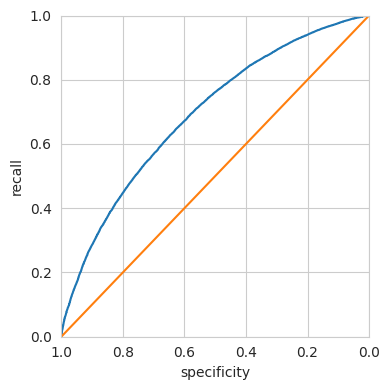

In [14]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:, 0], pos_label='default')
roc_df = pd.DataFrame({'recall': tpr, 'specificity': 1 - fpr})
ax = roc_df.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
ax.set_ylim(0, 1); ax.set_xlim(1, 0)
ax.plot((1, 0), (0, 1))
ax.set_xlabel('specificity'); ax.set_ylabel('recall')
plt.tight_layout(); plt.show()

0.6917072386901973
0.6917073165151092


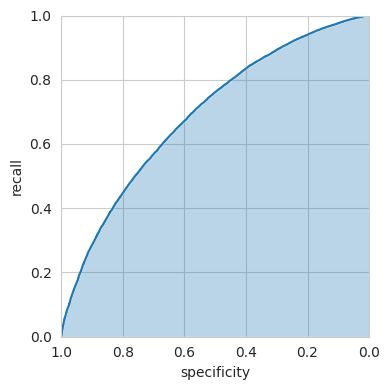

In [15]:
# AUC
print(np.sum(roc_df.recall[:-1] * np.diff(1 - roc_df.specificity)))
print(roc_auc_score([1 if yi == 'default' else 0 for yi in y], logit_reg.predict_proba(X)[:, 0]))

ax = roc_df.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
ax.set_ylim(0, 1); ax.set_xlim(1, 0)
ax.set_xlabel('specificity'); ax.set_ylabel('recall')
ax.fill_between(roc_df.specificity, 0, roc_df.recall, alpha=0.3)
plt.tight_layout(); plt.show()

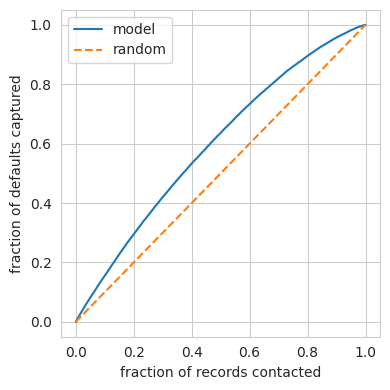

Lift in top 10%: 1.5570552688456618


In [16]:
# Lift / cumulative gains: sort by predicted default probability and track the share of defaults captured
score = logit_reg.predict_proba(X)[:, 0]
order = np.argsort(-score)
captured = np.cumsum(np.array(true_y)[order]) / true_y.sum()
frac = np.arange(1, len(score) + 1) / len(score)
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(frac, captured, label='model'); ax.plot([0, 1], [0, 1], '--', label='random')
ax.set_xlabel('fraction of records contacted'); ax.set_ylabel('fraction of defaults captured')
ax.legend(); plt.tight_layout(); plt.show()
print('Lift in top 10%:', captured[int(0.1 * len(score))] / 0.1)

## 5. Strategi untuk Data Tidak Seimbang
**Penjelasan teori.** Kalau kelas langka (fraud, gagal bayar, penyakit) jumlahnya kurang dari sekitar 1 sampai 10% record, model cenderung mengabaikannya. Beberapa solusinya:
- **Undersampling.** Semua record kelas langka dipertahankan, tetapi hanya sebagian acak dari kelas mayoritas. Sederhana, tetapi membuang informasi.
- **Oversampling atau up-weighting kelas langka.** Record kelas langka diduplikasi (bootstrap) atau diberi bobot lebih besar, sedangkan kelas mayoritas bisa di-**down-weight**.
- **Pembangkitan data.** **SMOTE** membuat record minoritas *sintetis* dengan interpolasi antara sebuah titik minoritas dan tetangga terdekatnya, sedangkan **ADASYN** berfokus pada area yang lebih sulit dipelajari.
- **Klasifikasi berbasis biaya.** Cutoff dipilih supaya biaya harapan paling kecil ketika biaya FN dan FP berbeda, bukan memakai 0,5 begitu saja.
- **Eksplorasi prediksi.** Periksa kurva **precision-recall**, sesuaikan threshold probabilitas, dan bandingkan decision boundary antar model.

In [17]:
full_train_set = pd.read_csv(DATA / 'full_train_set.csv.gz')
print(full_train_set.shape)
print('percentage of loans in default: ', 100 * np.mean(full_train_set.outcome == 'default'))

predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'
X = pd.get_dummies(full_train_set[predictors], prefix='', prefix_sep='', drop_first=True, dtype=int)
y = full_train_set[outcome]

full_model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000)
full_model.fit(X, y)
print('percentage of loans predicted to default: ', 100 * np.mean(full_model.predict(X) == 'default'))
print('ratio actual / predicted default rate  : ',
      np.mean(full_train_set.outcome == 'default') / np.mean(full_model.predict(X) == 'default'))

(119987, 19)
percentage of loans in default:  18.894546909248504


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


percentage of loans predicted to default:  0.3967096435447174
ratio actual / predicted default rate  :  47.6281512605042


Model hanya memprediksi sangat sedikit gagal bayar dibanding kenyataannya, artinya kelas yang langka tidak terdeteksi dengan baik. Sekarang dicoba dengan up-weighting.

In [18]:
# Oversampling / up-weighting
default_wt = 1 / np.mean(full_train_set.outcome == 'default')
wt = [default_wt if o == 'default' else 1 for o in full_train_set.outcome]
full_model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000)
full_model.fit(X, y, wt)
print('percentage of loans predicted to default (weighting): ', 100 * np.mean(full_model.predict(X) == 'default'))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


percentage of loans predicted to default (weighting):  57.621242301249296


In [19]:
# Undersampling: all defaults + an equal-sized random subset of paid-off loans
rng = np.random.default_rng(1)
idx_def = np.where(y == 'default')[0]
idx_paid = rng.choice(np.where(y == 'paid off')[0], size=len(idx_def), replace=False)
idx = np.concatenate([idx_def, idx_paid])
under_model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000).fit(X.iloc[idx], y.iloc[idx])
print('percentage of loans predicted to default (undersampling): ', 100 * np.mean(under_model.predict(X) == 'default'))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


percentage of loans predicted to default (undersampling):  42.60794919449607


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
# Data generation: SMOTE and ADASYN
X_resampled, y_resampled = SMOTE().fit_resample(X, y)
print('percentage of loans in default (SMOTE resampled): ', 100 * np.mean(y_resampled == 'default'))
full_model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000)
full_model.fit(X_resampled, y_resampled)
print('percentage of loans predicted to default (SMOTE): ', 100 * np.mean(full_model.predict(X) == 'default'))

X_resampled, y_resampled = ADASYN().fit_resample(X, y)
print('percentage of loans in default (ADASYN resampled): ', 100 * np.mean(y_resampled == 'default'))
full_model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000)
full_model.fit(X_resampled, y_resampled)
print('percentage of loans predicted to default (ADASYN): ', 100 * np.mean(full_model.predict(X) == 'default'))

percentage of loans in default (SMOTE resampled):  50.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


percentage of loans predicted to default (SMOTE):  29.321509830231605


percentage of loans in default (ADASYN resampled):  48.56040383751355


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


percentage of loans predicted to default (ADASYN):  27.174610582813134


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Eksplorasi Prediksi
Tiap classifier menghasilkan **decision boundary** yang berbeda. Di sini dibandingkan decision tree, LDA, regresi logistik, dan GAM pada data `loan3000` yang hanya punya dua prediktor.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


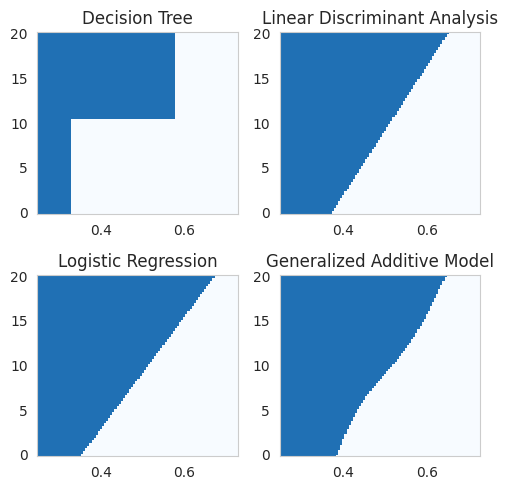

In [21]:
loan3000 = pd.read_csv(DATA / 'loan3000.csv')
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'
X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(random_state=1, criterion='entropy', min_impurity_decrease=0.003)
loan_tree.fit(X, y)
loan_lda = LinearDiscriminantAnalysis().fit(X, y)
logit_reg = LogisticRegression(penalty='l2', solver='liblinear').fit(X, y)
gam = LinearGAM(s(0) + s(1))
gam.gridsearch(X.values, [1 if yi == 'default' else 0 for yi in y], progress=False)

models = {'Decision Tree': loan_tree, 'Linear Discriminant Analysis': loan_lda,
          'Logistic Regression': logit_reg, 'Generalized Additive Model': gam}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
xvalues = np.arange(0.25, 0.73, 0.005)
yvalues = np.arange(-0.1, 20.1, 0.1)
xx, yy = np.meshgrid(xvalues, yvalues)
Xgrid = pd.DataFrame({'borrower_score': xx.ravel(), 'payment_inc_ratio': yy.ravel()})

boundary = {}
for i, (title, model) in enumerate(models.items()):
    ax = axes[i // 2, i % 2]
    predict = model.predict(Xgrid if 'Generalized' not in title else Xgrid.values)
    if 'Generalized' in title:
        Z = np.array([1 if z > 0.5 else 0 for z in predict])
    else:
        Z = np.array([1 if z == 'default' else 0 for z in predict])
    Z = Z.reshape(xx.shape)
    boundary[title] = yvalues[np.argmax(Z > 0, axis=0)]
    boundary[title][Z[-1, :] == 0] = yvalues[-1]
    ax.pcolormesh(xx, yy, Z, cmap='Blues', vmin=0.1, vmax=1.3, shading='auto')
    ax.set_title(title); ax.grid(True)
plt.tight_layout(); plt.show()

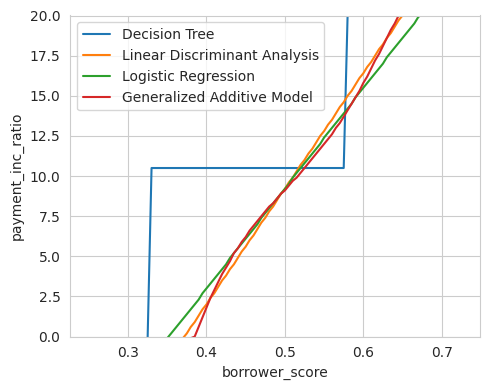

In [22]:
boundary['borrower_score'] = xvalues
boundaries = pd.DataFrame(boundary)
fig, ax = plt.subplots(figsize=(5, 4))
boundaries.plot(x='borrower_score', ax=ax)
ax.set_ylabel('payment_inc_ratio'); ax.set_ylim(0, 20)
plt.tight_layout(); plt.show()

## Poin Penting
- Classifier menghasilkan probabilitas, dan **cutoff** mengubahnya menjadi kelas. Cutoff sebaiknya mempertimbangkan biaya dari tiap jenis kesalahan.
- Naive Bayes, LDA, dan regresi logistik adalah baseline yang cepat dan mudah ditafsirkan. Regresi logistik memberi **odds ratio**.
- Evaluasi dengan **confusion matrix, precision/recall, ROC/AUC, dan lift**, jangan hanya akurasi, terutama untuk kelas yang langka.
- Untuk data tidak seimbang: lakukan under/oversampling, beri bobot, bangkitkan data sintetis (SMOTE/ADASYN), atau atur cutoff.